# LSTM en IMDb

Se va a emplear la capa LSTM para resolver el problema IMDB

In [2]:
from keras.datasets import imdb
from keras.preprocessing import sequence

max_features = 1000 # Palabras a considerar en el diccionario
max_len = 500       # Truncar en esa cantidad de palabras

(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features)

input_train = sequence.pad_sequences(input_train, maxlen=max_len)
input_test = sequence.pad_sequences(input_test, maxlen=max_len)
print('input_train shape', input_train.shape)
print('input_test shape', input_test.shape)

2025-12-07 22:10:36.745107: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765156236.764808 3246893 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765156236.772616 3246893 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765156236.807379 3246893 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765156236.807397 3246893 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765156236.807399 3246893 computation_placer.cc:177] computation placer alr

input_train shape (25000, 500)
input_test shape (25000, 500)


In [5]:
from keras.layers import LSTM, Embedding, Dense
from keras.models import Sequential

emb_size = 32   # Tamaño del vector embedding

model = Sequential()
model.add(Embedding(max_features, emb_size))
model.add(LSTM(32))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

history = model.fit(input_train, y_train, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10


2025-10-13 21:10:33.575172: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 40000000 exceeds 10% of free system memory.
I0000 00:00:1760400638.065337 1432148 cuda_dnn.cc:529] Loaded cuDNN version 90300


157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - acc: 0.5670 - loss: 0.6735 - val_acc: 0.7854 - val_loss: 0.4889
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc: 0.7580 - loss: 0.5100 - val_acc: 0.8130 - val_loss: 0.4306
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc: 0.7893 - loss: 0.4573 - val_acc: 0.7966 - val_loss: 0.4474
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.8131 - loss: 0.4211 - val_acc: 0.8324 - val_loss: 0.3873
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.8202 - loss: 0.4109 - val_acc: 0.8030 - val_loss: 0.4879
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - acc: 0.8253 - loss: 0.4041 - val_acc: 0.8086 - val_loss: 0.4267
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.8426 - loss: 0.3616 - val_acc: 0.8414 - val_loss: 0.3736
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.8504 - loss: 0.3488 - val_acc: 0.8470 - val_loss: 0.3579
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc

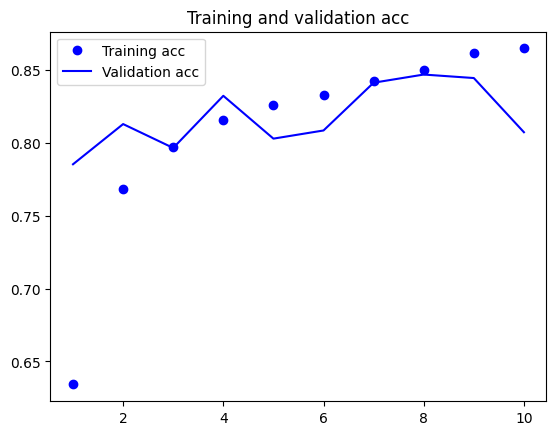

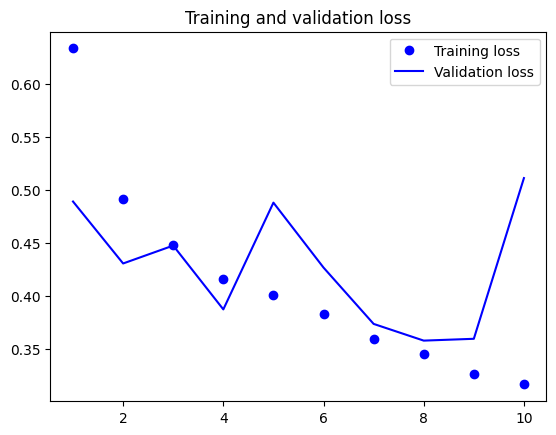

In [6]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation acc')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

Es ligeramente mejor que la version RNN de [6.2.0](/6.2.0.recurrent-neuronal-networks.ipynb). En el mejor momento se hacerca al 85% de validacion. El modelo da indicios de *overfitting* en la iteracion 8.

Al incrementar la cantidad de palabras disponibles el *accuracy* del modelo mejora:

In [10]:
max_len = 1000
(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features)
input_train = sequence.pad_sequences(input_train, maxlen=max_len)
input_test = sequence.pad_sequences(input_test, maxlen=max_len)

model = Sequential()
model.add(Embedding(max_features, emb_size))
model.add(LSTM(32))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

history = model.fit(input_train, y_train, epochs=20, batch_size=128, validation_split=0.2)

Epoch 1/20


2025-10-13 21:22:12.267943: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 80000000 exceeds 10% of free system memory.


157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - acc: 0.5499 - loss: 0.6833 - val_acc: 0.7766 - val_loss: 0.5030
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - acc: 0.7419 - loss: 0.5291 - val_acc: 0.7346 - val_loss: 0.5210
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - acc: 0.7895 - loss: 0.4560 - val_acc: 0.8064 - val_loss: 0.4327
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - acc: 0.8056 - loss: 0.4288 - val_acc: 0.8296 - val_loss: 0.4020
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - acc: 0.8226 - loss: 0.4021 - val_acc: 0.8386 - val_loss: 0.3778
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - acc: 0.8274 - loss: 0.3902 - val_acc: 0.8512 - val_loss: 0.3502
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - acc: 0.8485 - loss: 0.3535 - val_acc: 0.8320 - val_loss: 0.3880
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - acc: 0.8509 - loss: 0.3493 - val_acc: 0.8564 - val_loss: 0.3363
Epoch 9/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - ac

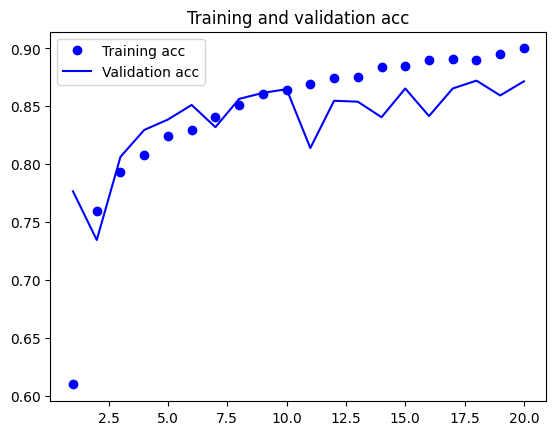

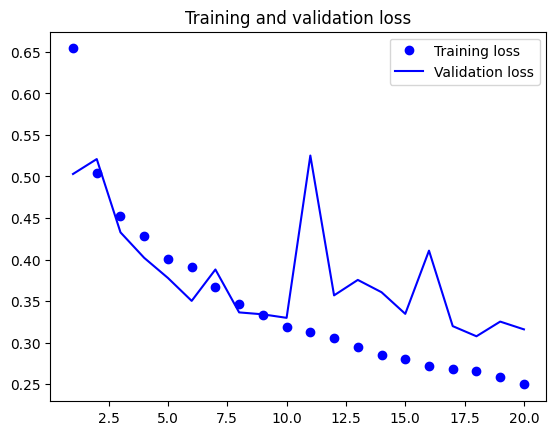

In [11]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation acc')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

Permitiendo un largo de 1000 palabras se logra alcanzar un 87% de *accuracy* en validacion. 

Luego de 20 epocas el modelo da indicios de poder mejorar su *accuracy* en validacion de entrenar mas.

La version Densa del capitulo [3](/3.4.IMDb.ipynb) logra un rendimiento similar pero recordar que esta usa 10000 palabras (x10) y considera la totalidad de las reseñas (no trunca).

La busqueda de patrones temporales ayuda en la clasificacion de reseñas positivas|negativas. Con menos palabras se pueden lograr mejores clasificaciones.

## Incrementar el tamaño del embedding

Incrementar el tamaño del vector embedding permite representaciones mas ricas de los textos.

In [ ]:
from keras.layers import LSTM, Embedding, Dense
from keras.models import Sequential

emb_size = 128   # Tamaño del vector embedding

model = Sequential()
model.add(Embedding(max_features, emb_size))
model.add(LSTM(32))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

history = model.fit(input_train, y_train, epochs=10, batch_size=128, validation_split=0.2)

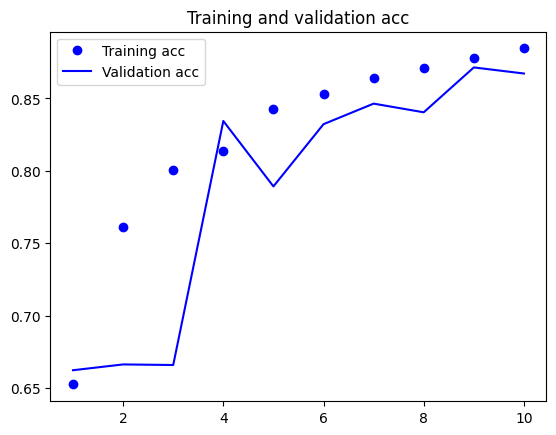

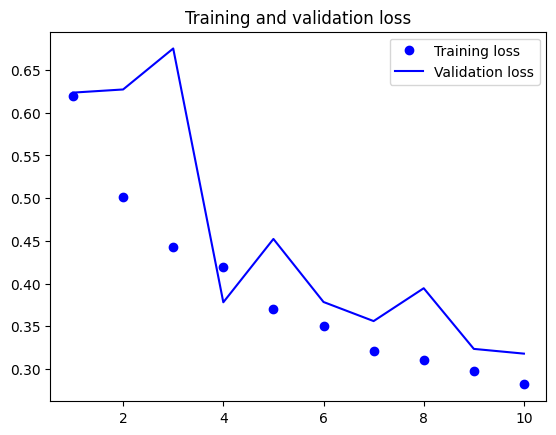

In [4]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation acc')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

Mejoro, paso de 85% de precision a 87%.